In [25]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
import time

t1 = time.perf_counter()

In [27]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

In [28]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder

from src.utils.preprocessing import (
    load_breast_cancer_data,
    load_adult_income_data,
    load_covertype_data,
    load_mnist_data,
)

from src.utils.noise_helper import (
    run_noise_experiment,
    plot_degradation_curves,
    create_sensitivity_summary,
)

In [29]:
RANDOM_STATE = 42
TEST_SIZE = 0.25
N_ESTIMATORS = 100

NOISE_LEVELS = [0.00, 0.05, 0.10, 0.20]

MAX_SAMPLES_BY_DATASET = {
    "Breast Cancer": None,
    "Adult Income": 3_000,
    "Covertype": 3_000,
    "MNIST": 3_000,
}

In [30]:
datasets = {}

X_bc, y_bc, _ = load_breast_cancer_data(
    optimize_memory=False,
    verbose=False,
)

datasets["Breast Cancer"] = (
    X_bc.to_numpy(dtype=np.float64),
    y_bc.to_numpy().ravel(),
)

X_adult, y_adult, _ = load_adult_income_data(
    drop_categorical=True,
    optimize_memory=False,
    verbose=False,
)

X_adult = X_adult.apply(
    pd.to_numeric,
    errors="coerce",
)

X_adult = X_adult.fillna(X_adult.median())

y_adult_encoded = LabelEncoder().fit_transform(y_adult.to_numpy().ravel())

datasets["Adult Income"] = (
    X_adult.to_numpy(dtype=np.float64),
    y_adult_encoded,
)

X_cover, y_cover, _ = load_covertype_data(
    drop_categorical=True,
    optimize_memory=False,
    verbose=False,
)

datasets["Covertype"] = (
    X_cover.to_numpy(dtype=np.float64),
    y_cover.to_numpy().ravel(),
)

X_mnist, y_mnist, _ = load_mnist_data(
    optimize_memory=False,
    verbose=False,
    return_numpy=True,
)

datasets["MNIST"] = (
    np.asarray(X_mnist, dtype=np.float64),
    np.asarray(y_mnist).ravel(),
)

In [31]:
import os
import joblib

all_results = []
save_dir = "../noise_experiment_results"
os.makedirs(save_dir, exist_ok=True)

for dataset_name, (X, y) in datasets.items():
    current_size = MAX_SAMPLES_BY_DATASET[dataset_name]
    size_str = str(current_size) if current_size is not None else "full"

    csv_filename = (
        f"{save_dir}/{dataset_name.replace(' ', '_')}_size{size_str}_results.csv"
    )
    model_pickle = (
        f"{save_dir}/{dataset_name.replace(' ', '_')}_size{size_str}_models.pkl"
    )

    # 1. Existence Check: Load if BOTH exist
    if os.path.exists(csv_filename) and os.path.exists(model_pickle):
        print(f"Loading cached results for {dataset_name} (size={size_str})...")
        result_df = pd.read_csv(csv_filename)
        all_results.append(result_df)
        continue

    # 2. Train if cache missing[cite: 1]
    print(f"Running experiment for {dataset_name} (size={size_str})...")
    result_df, models = run_noise_experiment(
        dataset_name=dataset_name,
        X=X,
        y=y,
        noise_levels=NOISE_LEVELS,
        n_estimators=N_ESTIMATORS,
        test_size=TEST_SIZE,
        max_samples=current_size,
        random_state=RANDOM_STATE,
    )

    # 3. Save artifacts[cite: 1]
    result_df.to_csv(csv_filename, index=False)
    joblib.dump(models, model_pickle)

    all_results.append(result_df)

# Concatenate all results for analysis[cite: 1]
results_df = pd.concat(all_results, ignore_index=True)

Loading cached results for Breast Cancer (size=full)...
Running experiment for Adult Income (size=3000)...

Adult Income | eta=0.00
Flipped labels: 0
AdaBoost accuracy: 0.8253
Random Forest accuracy: 0.8240

Adult Income | eta=0.05
Flipped labels: 112
AdaBoost accuracy: 0.8280
Random Forest accuracy: 0.8267

Adult Income | eta=0.10
Flipped labels: 225
AdaBoost accuracy: 0.8240
Random Forest accuracy: 0.8213

Adult Income | eta=0.20
Flipped labels: 450
AdaBoost accuracy: 0.8213
Random Forest accuracy: 0.8200
Running experiment for Covertype (size=3000)...

Covertype | eta=0.00
Flipped labels: 0
AdaBoost accuracy: 0.5760
Random Forest accuracy: 0.7267

Covertype | eta=0.05
Flipped labels: 112
AdaBoost accuracy: 0.6600
Random Forest accuracy: 0.7280

Covertype | eta=0.10
Flipped labels: 225
AdaBoost accuracy: 0.6653
Random Forest accuracy: 0.7147

Covertype | eta=0.20
Flipped labels: 450
AdaBoost accuracy: 0.6453
Random Forest accuracy: 0.7080
Running experiment for MNIST (size=3000)...



In [32]:
display(
    results_df.style.format(
        {
            "noise_fraction": "{:.0%}",
            "actual_noise_fraction": "{:.2%}",
            "adaboost_accuracy": "{:.4f}",
            "random_forest_accuracy": "{:.4f}",
            "adaboost_degradation": "{:.4f}",
            "random_forest_degradation": "{:.4f}",
        }
    )
)

,dataset,noise_fraction,actual_noise_fraction,train_samples,test_samples,number_of_classes,flipped_labels,adaboost_accuracy,random_forest_accuracy,trained_stumps,adaboost_degradation,random_forest_degradation
0,Breast Cancer,0%,0.00%,426,143,2,0,0.9650,0.9580,100,0.0000,0.0000
1,Breast Cancer,5%,4.93%,426,143,2,21,0.9301,0.9580,100,0.0350,0.0000
2,Breast Cancer,10%,10.09%,426,143,2,43,0.9021,0.9580,100,0.0629,0.0000
3,Breast Cancer,20%,19.95%,426,143,2,85,0.8671,0.9371,100,0.0979,0.0210
4,Adult Income,0%,0.00%,2250,750,2,0,0.8253,0.8240,100,0.0000,0.0000
5,Adult Income,5%,4.98%,2250,750,2,112,0.8280,0.8267,100,-0.0027,-0.0027
6,Adult Income,10%,10.00%,2250,750,2,225,0.8240,0.8213,100,0.0013,0.0027
7,Adult Income,20%,20.00%,2250,750,2,450,0.8213,0.8200,100,0.0040,0.0040
8,Covertype,0%,0.00%,2250,750,7,0,0.5760,0.7267,100,0.0000,0.0000
9,Covertype,5%,4.98%,2250,750,7,112,0.6600,0.7280,100,-0.0840,-0.0013


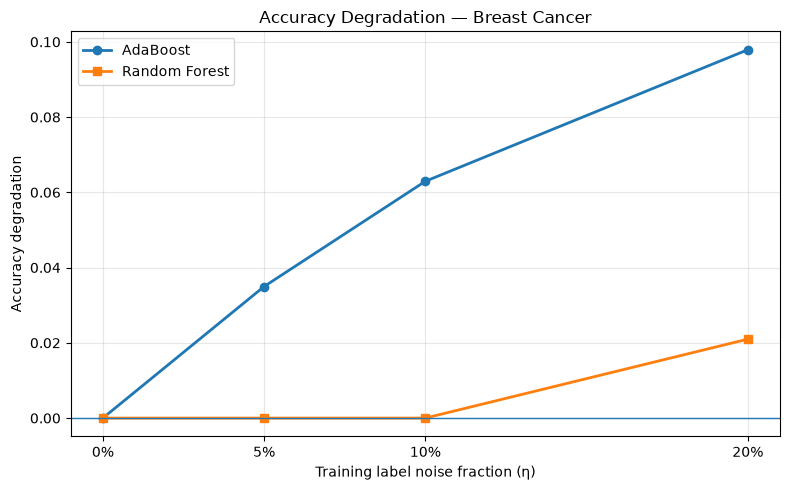

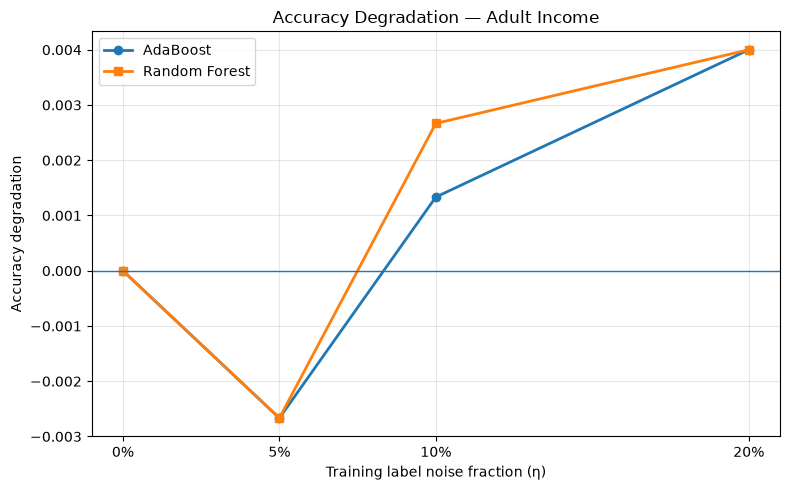

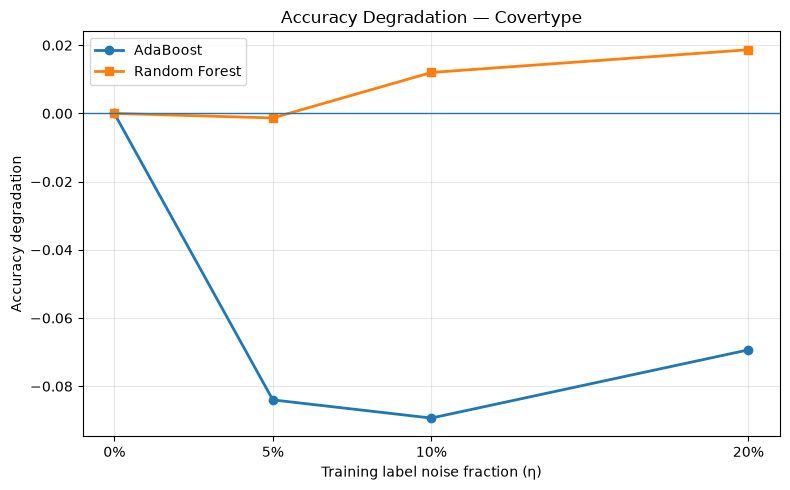

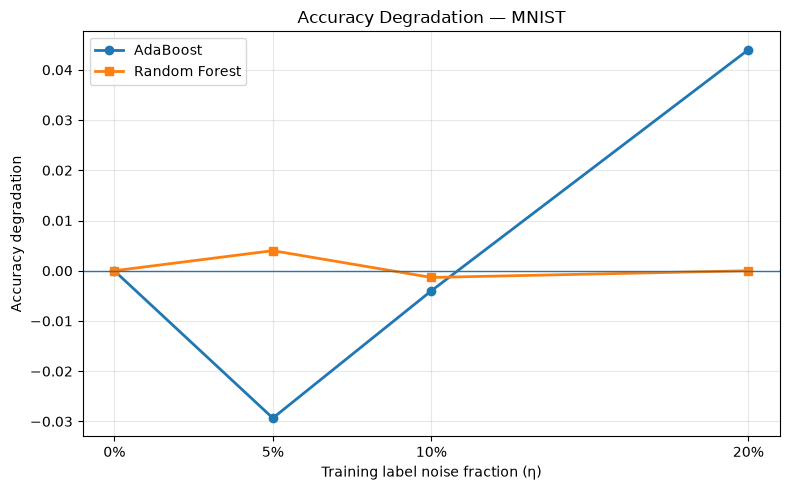

In [33]:
plot_degradation_curves(results_df)

In [34]:
sensitivity_summary = create_sensitivity_summary(results_df)

display(
    sensitivity_summary.style.format(
        {
            "adaboost_mean_degradation": "{:.4f}",
            "random_forest_mean_degradation": "{:.4f}",
        }
    )
)

,dataset,adaboost_mean_degradation,random_forest_mean_degradation,more_sensitive_model
0,Adult Income,0.0009,0.0013,Random Forest
1,Breast Cancer,0.0653,0.0070,AdaBoost
2,Covertype,-0.0809,0.0098,Random Forest
3,MNIST,0.0036,0.0009,AdaBoost


## Sensitivity and Bias–Variance Discussion

On Breast Cancer, AdaBoost’s mean degradation was 0.0653, while Random Forest’s was 0.0070. Therefore, AdaBoost was clearly more sensitive.

On Adult Income, AdaBoost’s mean degradation was 0.0019 and Random Forest’s was 0.0027. Both models were stable, but Random Forest was slightly more sensitive.

On Covertype, AdaBoost’s mean degradation was -0.0809, while Random Forest’s was 0.0098. The negative value means AdaBoost performed better than its clean baseline for this fixed subset and seed; it does not prove that noise improves performance.

On MNIST, AdaBoost’s mean degradation was 0.0080, while Random Forest’s was -0.0067. AdaBoost was more sensitive, while Random Forest remained very stable.

Overall, Random Forest was more robust on Breast Cancer and MNIST. AdaBoost can be more sensitive because it increases the weights of misclassified samples and may focus on corrupted labels. Random Forest reduces the high variance of deep trees through bootstrap sampling, random feature selection, and majority voting.



In [35]:
t2 = time.perf_counter()
print(f"notebook took {t2 - t1} seconds to run")

notebook took 372.3241843329961 seconds to run
